In [1]:
# Aggiornamento del package manager
%pip install --upgrade pip

# Installazione PyTorch con supporto CUDA 12.4 (ottimizzato per GPU NVIDIA moderne)
%pip install torch --index-url https://download.pytorch.org/whl/cu124

# Installazione librerie scientifiche e diagnostica
%pip install numpy scipy pandas matplotlib tqdm ipykernel

# Verifica rapida del rilevamento GPU
import torch
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available:  {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device Name:     {torch.cuda.get_device_name(0)}")

   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 1.8/1.8 MB 26.4 MB/s  0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 26.1.2
    Uninstalling pip-26.1.2:
      Successfully uninstalled pip-26.1.2
Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://download.pytorch.org/whl/cu124
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement torch (from versions: none)
ERROR: No matching distribution found for torch


  Using cached pandas-3.0.5-cp314-cp314-win_amd64.whl.metadata (19 kB)
  Using cached matplotlib-3.11.1-cp314-cp314-win_amd64.whl.metadata (80 kB)
  Using cached tqdm-4.70.0-py3-none-any.whl.metadata (57 kB)
  Using cached tzdata-2026.3-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp314-cp314-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp314-cp314-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   --------------------- ------------------ 6.8/12.6 MB 38.9 MB/s eta 0:00:01
   ---------------------------------------- 12.6/12.6 MB 36.6 MB/s  0:00:00
   ---------------------------------------- 0.0/37.4 MB ? eta -:--:--


ModuleNotFoundError: No module named 'torch'

Esecuzione su GPU: NVIDIA GeForce RTX 4090
Inizio benchmark GPU su 500 reti sintetiche...


GPU Inference Pipeline: 100%|██████████| 500/500 [02:22<00:00,  3.51it/s]



Benchmark completato in 142.51s (Media: 285.02 ms/grafo).
Dataset salvato in: Diagnostics_plots\diagnostics_dataset_MultiCurve_N500_Adam50_Lbfgs40_GPU.csv

Grafici esportati:
  -> Diagnostics_plots\multicurve_diagnostics_MultiCurve_N500_Adam50_Lbfgs40_GPU.pdf
  -> Diagnostics_plots\multicurve_diagnostics_MultiCurve_N500_Adam50_Lbfgs40_GPU.png


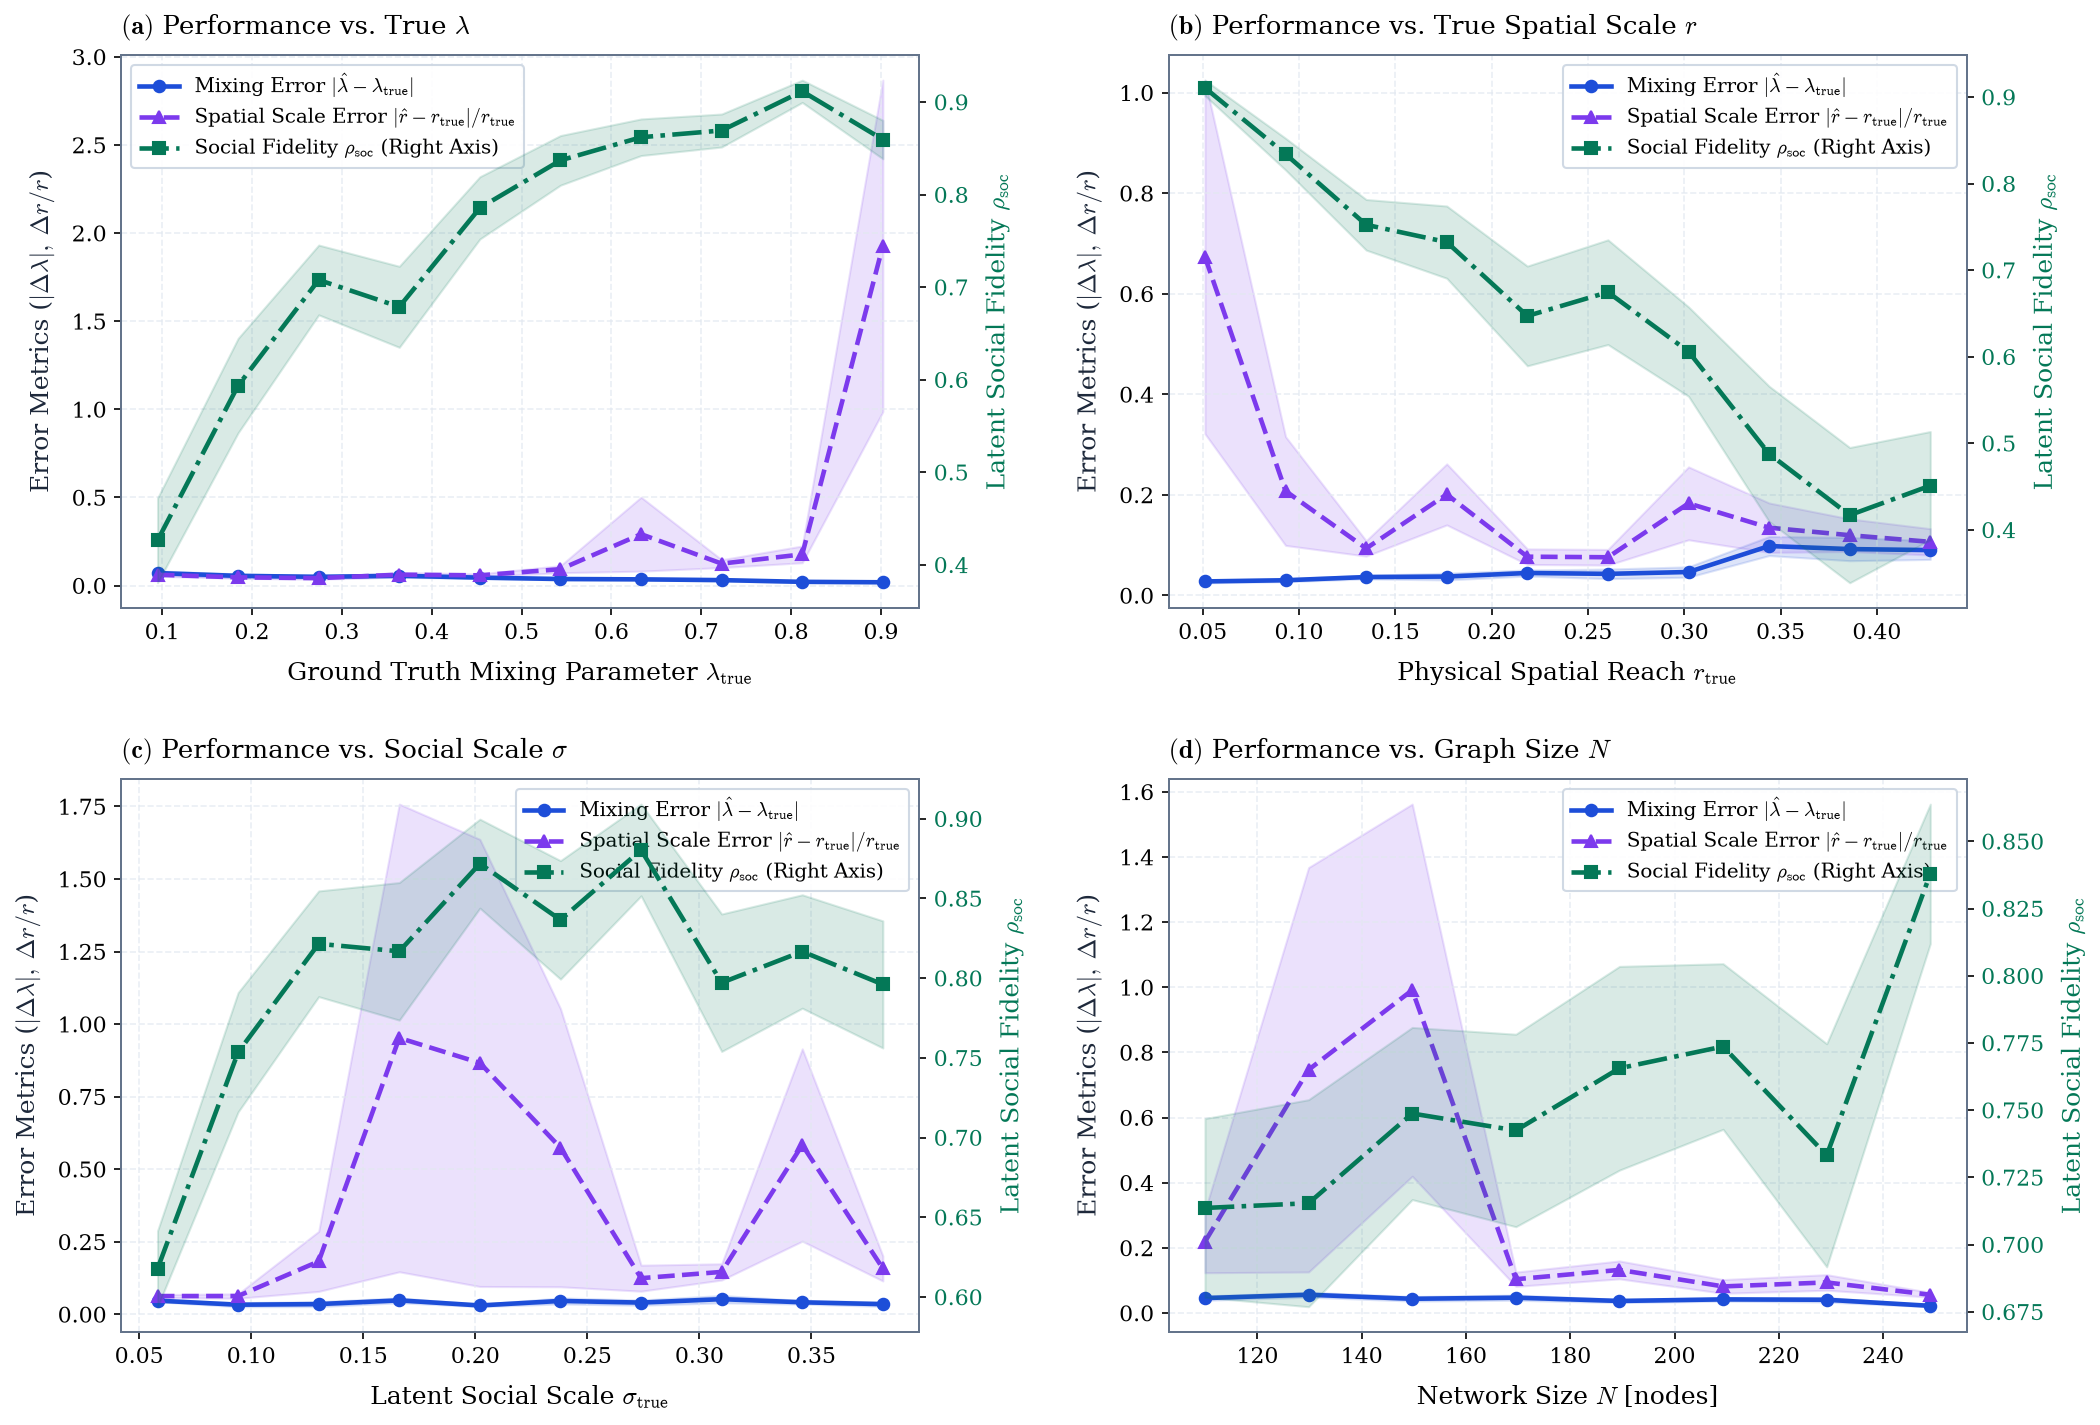

In [2]:
# ======================================================================
# MULTI-CURVE DIAGNOSTICS BENCHMARK (GPU-ACCELERATED FOR WINDOWS / CUDA)
# ======================================================================

import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from scipy.spatial.distance import cdist
from scipy.stats import binned_statistic, pearsonr, spearmanr
from tqdm import tqdm

# Impostazioni dispositivo GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device.type == "cuda":
    torch.backends.cudnn.benchmark = True
    print(f"Esecuzione su GPU: {torch.cuda.get_device_name(0)}")
else:
    print("ATTENZIONE: CUDA non rilevata, fallback su CPU.")

# ======================================================================
# 1. CONFIGURAZIONE MODULARE DEI SUBPLOT E DELLE MULTI-CURVE
# ======================================================================

X_SUBPLOTS = [
    {
        "col": "lambda_true",
        "label": r"Ground Truth Mixing Parameter $\lambda_{\mathrm{true}}$",
        "bins": 10,
        "title": r"$\mathbf{(a)}$ Performance vs. True $\lambda$",
    },
    {
        "col": "r_true",
        "label": r"Physical Spatial Reach $r_{\mathrm{true}}$",
        "bins": 10,
        "title": r"$\mathbf{(b)}$ Performance vs. True Spatial Scale $r$",
    },
    {
        "col": "sigma_true",
        "label": r"Latent Social Scale $\sigma_{\mathrm{true}}$",
        "bins": 10,
        "title": r"$\mathbf{(c)}$ Performance vs. Social Scale $\sigma$",
    },
    {
        "col": "N",
        "label": r"Network Size $N$ [nodes]",
        "bins": 8,
        "title": r"$\mathbf{(d)}$ Performance vs. Graph Size $N$",
    },
]

Y_CURVES = [
    {
        "col": "err_lam_abs",
        "label": r"Mixing Error $|\hat{\lambda} - \lambda_{\mathrm{true}}|$",
        "axis": "primary",
        "color": "#1d4ed8",
        "marker": "o",
        "linestyle": "-",
        "lw": 2.2,
    },
    {
        "col": "err_r_rel",
        "label": (
            r"Spatial Scale Error $|\hat{r} - r_{\mathrm{true}}| /"
            r" r_{\mathrm{true}}$"
        ),
        "axis": "primary",
        "color": "#7c3aed",
        "marker": "^",
        "linestyle": "--",
        "lw": 2.2,
    },
    {
        "col": "rho_soc_pearson",
        "label": r"Social Fidelity $\rho_{\mathrm{soc}}$ (Right Axis)",
        "axis": "secondary",
        "color": "#047857",
        "marker": "s",
        "linestyle": "-.",
        "lw": 2.2,
    },
]

# Iperparametri inferenza
N_NETWORKS = 500
ETA_ADAM = 0.04
T_ADAM = 50
T_LBFGS = 40
OUTPUT_DIR = "Diagnostics_plots"
os.makedirs(OUTPUT_DIR, exist_ok=True)
tag = f"MultiCurve_N{N_NETWORKS}_Adam{T_ADAM}_Lbfgs{T_LBFGS}_GPU"


# ======================================================================
# 2. GENERAZIONE SINTETICA (DETERMINISTICA)
# ======================================================================
def sample_synthetic_network_exhaustive(seed):
    np.random.seed(seed)
    N = int(np.random.randint(100, 260))
    lambda_true = float(np.random.uniform(0.05, 0.95))
    r_true = float(np.exp(np.random.uniform(np.log(0.03), np.log(0.45))))
    sigma_true = float(np.exp(np.random.uniform(np.log(0.04), np.log(0.40))))
    d_s = 2

    X_phys = np.random.uniform(0.0, 1.0, size=(N, 2))
    K_gmm = int(np.random.randint(2, 9))
    gmm_means = np.random.uniform(0.1, 0.9, size=(K_gmm, d_s))
    gmm_cov_diags = np.random.uniform(0.01, 0.05, size=(K_gmm, d_s))
    gmm_covs = [np.diag(gmm_cov_diags[k]) for k in range(K_gmm)]
    gmm_weights = np.random.dirichlet(np.ones(K_gmm))
    comp_choices = np.random.choice(K_gmm, size=N, p=gmm_weights)

    S_true = np.zeros((N, d_s))
    for k in range(K_gmm):
        idx_k = np.where(comp_choices == k)[0]
        if len(idx_k) > 0:
            S_true[idx_k] = np.random.multivariate_normal(
                gmm_means[k], gmm_covs[k], size=len(idx_k)
            )

    S_min, S_max = S_true.min(axis=0), S_true.max(axis=0)
    S_true = (S_true - S_min) / (S_max - S_min + 1e-9)

    D_phys = cdist(X_phys, X_phys)
    np.fill_diagonal(D_phys, 1e9)
    D_soc = cdist(S_true, S_true)
    np.fill_diagonal(D_soc, 1e9)

    K_sp = np.exp(-D_phys / r_true)
    np.fill_diagonal(K_sp, 0.0)
    K_soc = np.exp(-D_soc / sigma_true)
    np.fill_diagonal(K_soc, 0.0)

    W_raw = (1.0 - lambda_true) * K_sp + lambda_true * K_soc
    row_sum = W_raw.sum(axis=1, keepdims=True) + 1e-12
    W_pred_clean = 0.5 * (W_raw / row_sum + W_raw / row_sum.T)

    iu, ju = np.triu_indices(N, k=1)

    metadata = {
        "N": N,
        "d_s": d_s,
        "lambda_true": lambda_true,
        "r_true": r_true,
        "sigma_true": sigma_true,
        "K_gmm": K_gmm,
        "D_phys_mean": float(D_phys[iu, ju].mean()),
        "D_soc_mean": float(D_soc[iu, ju].mean()),
    }

    tensors = {
        "N": N,
        "lambda_true": lambda_true,
        "r_true": r_true,
        "sigma_true": sigma_true,
        "D_phys": D_phys.astype(np.float32),
        "W_pred_clean": W_pred_clean.astype(np.float32),
        "iu": iu.astype(np.int64),
        "ju": ju.astype(np.int64),
        "eye_mask": (1.0 - np.eye(N)).astype(np.float32),
        "D_soc_flat": D_soc[iu, ju].astype(np.float64),
    }
    return metadata, tensors


# ======================================================================
# 3. GPU INFERENCE ENGINE
# ======================================================================
def run_gpu_inference(
    net_idx, seed_poisson, net_item, ETA_ADAM, T_ADAM, T_LBFGS, device
):
    t0 = time.perf_counter()

    N = net_item["N"]
    D_phys = net_item["D_phys"]
    W_clean = net_item["W_pred_clean"]
    iu = net_item["iu"]
    ju = net_item["ju"]
    eye_mask = net_item["eye_mask"]

    # 1. Campionamento Poissoniano su CPU con seed fisso
    rng = np.random.RandomState(seed_poisson)
    rate = N * W_clean[iu, ju]
    w_obs_u = rng.poisson(rate).astype(np.float32)

    W_obs = np.zeros((N, N), dtype=np.float32)
    W_obs[iu, ju] = w_obs_u
    W_obs[ju, iu] = w_obs_u

    c_target = float(W_obs.sum(axis=1).mean())
    obs_density = float((w_obs_u > 0).mean())
    r0 = float(2.0 * D_phys.min(axis=1).mean())
    log_r0 = float(np.log(r0))

    # 2. Inizializzazione spettrale SVD (identica)
    K_sp0 = np.exp(-D_phys / r0)
    np.fill_diagonal(K_sp0, 0.0)
    s_sp0 = K_sp0.sum(axis=1, keepdims=True) + 1e-12
    W_sp0 = 0.5 * c_target * (K_sp0 / s_sp0 + K_sp0 / s_sp0.T)
    R_init = np.maximum(0.0, W_obs - W_sp0)
    U, sv, _ = np.linalg.svd(R_init, full_matrices=False)
    S_init = U[:, :2] * np.sqrt(sv[:2])
    S_init = (S_init - S_init.mean(axis=0)) / (S_init.std() + 1e-9) * 3.0

    # 3. Caricamento tensori su VRAM GPU
    D_phys_t = torch.from_numpy(D_phys).to(device, non_blocking=True)
    W_obs_u_t = torch.from_numpy(w_obs_u).to(device, non_blocking=True)
    iu_t = torch.from_numpy(iu).to(device, non_blocking=True)
    ju_t = torch.from_numpy(ju).to(device, non_blocking=True)
    eye_mask_t = torch.from_numpy(eye_mask).to(device, non_blocking=True)

    logit_lam = torch.tensor(0.0, device=device, requires_grad=True)
    log_r = torch.tensor(log_r0, device=device, requires_grad=True)
    S_param = torch.tensor(
        S_init, dtype=torch.float32, device=device, requires_grad=True
    )

    # 4. Ottimizzazione Adam su GPU
    adam_opt = torch.optim.Adam(
        [
            {"params": [logit_lam], "lr": ETA_ADAM * 2.0},
            {"params": [log_r], "lr": ETA_ADAM},
            {"params": [S_param], "lr": ETA_ADAM * 5.0},
        ]
    )

    for _ in range(T_ADAM):
        adam_opt.zero_grad(set_to_none=True)
        lam = torch.sigmoid(logit_lam)
        r = torch.exp(torch.clamp(log_r, log_r0 - 3.0, log_r0 + 3.0))

        K_sp = torch.exp(-D_phys_t / r) * eye_mask_t
        D_soc = torch.cdist(S_param, S_param)
        K_soc = torch.exp(-D_soc) * eye_mask_t

        W_raw_t = (1.0 - lam) * K_sp + lam * K_soc
        rs = W_raw_t.sum(dim=1, keepdim=True) + 1e-12
        W_pred_t = 0.5 * c_target * (W_raw_t / rs + W_raw_t / rs.t())

        wu = W_pred_t[iu_t, ju_t]
        loss = (wu - W_obs_u_t * torch.log(wu + 1e-12)).sum() + 0.5 * (
            (log_r - log_r0) / 2.0
        ) ** 2
        loss.backward()
        adam_opt.step()

    # 5. Ottimizzazione L-BFGS su GPU
    lbfgs = torch.optim.LBFGS(
        [logit_lam, log_r, S_param],
        lr=0.5,
        max_iter=T_LBFGS,
        history_size=10,
        line_search_fn="strong_wolfe",
    )

    def closure():
        lbfgs.zero_grad(set_to_none=True)
        lam = torch.sigmoid(logit_lam)
        r = torch.exp(torch.clamp(log_r, log_r0 - 3.0, log_r0 + 3.0))

        K_sp = torch.exp(-D_phys_t / r) * eye_mask_t
        D_soc = torch.cdist(S_param, S_param)
        K_soc = torch.exp(-D_soc) * eye_mask_t

        W_raw_t = (1.0 - lam) * K_sp + lam * K_soc
        rs = W_raw_t.sum(dim=1, keepdim=True) + 1e-12
        W_pred_t = 0.5 * c_target * (W_raw_t / rs + W_raw_t / rs.t())

        wu = W_pred_t[iu_t, ju_t]
        loss = (wu - W_obs_u_t * torch.log(wu + 1e-12)).sum() + 0.5 * (
            (log_r - log_r0) / 2.0
        ) ** 2
        loss.backward()
        return loss

    opt_success = True
    final_loss = 0.0
    try:
        final_loss = float(lbfgs.step(closure).item())
        lam_hat = float(torch.sigmoid(logit_lam).item())
        r_hat = float(
            torch.exp(torch.clamp(log_r, log_r0 - 3.0, log_r0 + 3.0)).item()
        )

        S_hat = S_param.detach().cpu().numpy()
        D_soc_hat = cdist(S_hat, S_hat)[iu, ju]
        D_soc_gt = net_item["D_soc_flat"]

        rho_soc, _ = pearsonr(D_soc_hat, D_soc_gt)
        spearman_soc, _ = spearmanr(D_soc_hat, D_soc_gt)
        if np.isnan(rho_soc):
            rho_soc = 0.0
        if np.isnan(spearman_soc):
            spearman_soc = 0.0
    except Exception:
        opt_success = False
        lam_hat = float(torch.sigmoid(logit_lam).item())
        r_hat = r0
        rho_soc = 0.0
        spearman_soc = 0.0

    t_elapsed = time.perf_counter() - t0

    return {
        "network_idx": net_idx,
        "opt_success": opt_success,
        "runtime_sec": t_elapsed,
        "lam_hat": lam_hat,
        "r_hat": r_hat,
        "err_lam_abs": abs(lam_hat - net_item["lambda_true"]),
        "err_lam_signed": lam_hat - net_item["lambda_true"],
        "err_r_rel": abs(r_hat - net_item["r_true"]) / net_item["r_true"],
        "err_r_signed_rel": (r_hat - net_item["r_true"]) / net_item["r_true"],
        "rho_soc_pearson": rho_soc,
        "rho_soc_spearman": spearman_soc,
        "c_target": c_target,
        "obs_density": obs_density,
        "loss_final_lbfgs": final_loss,
    }


# ======================================================================
# 4. ESECUZIONE BENCHMARK PIPELINE
# ======================================================================
print(f"Inizio benchmark GPU su {N_NETWORKS} reti sintetiche...")
meta_records = []
worker_results = []

t_start = time.time()

for i in tqdm(range(N_NETWORKS), desc="GPU Inference Pipeline"):
    # 1. Generazione grafo
    meta, tensors = sample_synthetic_network_exhaustive(seed=6000 + i)
    meta["network_idx"] = i
    meta_records.append(meta)

    # 2. Ottimizzazione GPU
    res = run_gpu_inference(
        net_idx=i,
        seed_poisson=95000 + i,
        net_item=tensors,
        ETA_ADAM=ETA_ADAM,
        T_ADAM=T_ADAM,
        T_LBFGS=T_LBFGS,
        device=device,
    )
    worker_results.append(res)

t_total = time.time() - t_start
print(
    f"\nBenchmark completato in {t_total:.2f}s (Media:"
    f" {(t_total/N_NETWORKS)*1000:.2f} ms/grafo)."
)

df_meta = pd.DataFrame(meta_records)
df_worker = pd.DataFrame(worker_results)
df_full = pd.merge(df_meta, df_worker, on="network_idx")

csv_path = os.path.join(OUTPUT_DIR, f"diagnostics_dataset_{tag}.csv")
df_full.to_csv(csv_path, index=False)
print(f"Dataset salvato in: {csv_path}")

# ======================================================================
# 5. PLOTTING MULTI-CURVA SU OGNI SUBPLOT
# ======================================================================
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif", "Times New Roman", "Computer Modern Roman"],
    "mathtext.fontset": "cm",
    "axes.labelsize": 12.0,
    "axes.titlesize": 12.5,
    "xtick.labelsize": 10.5,
    "ytick.labelsize": 10.5,
    "legend.fontsize": 9.5,
    "axes.edgecolor": "#64748b",
    "axes.linewidth": 0.9,
    "grid.color": "#e2e8f0",
    "grid.linestyle": "--",
    "grid.alpha": 0.7,
    "figure.dpi": 150,
})

n_plots = len(X_SUBPLOTS)
n_cols = 2
n_rows = (n_plots + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows, n_cols, figsize=(14.5, 5.0 * n_rows), squeeze=False
)
axes_flat = axes.flatten()

for p_idx, x_spec in enumerate(X_SUBPLOTS):
    ax_prim = axes_flat[p_idx]
    x_col = x_spec["col"]
    x_label = x_spec["label"]
    n_bins = x_spec["bins"]
    subplot_title = x_spec.get("title", f"Metrics vs {x_col}")

    x_vals = df_full[x_col].values

    # Asse secondario
    has_sec = any(y.get("axis") == "secondary" for y in Y_CURVES)
    ax_sec = ax_prim.twinx() if has_sec else None

    handles, labels = [], []

    for y_spec in Y_CURVES:
        y_col = y_spec["col"]
        y_label = y_spec["label"]
        y_axis_type = y_spec.get("axis", "primary")
        color = y_spec["color"]
        marker = y_spec.get("marker", "o")
        ls = y_spec.get("linestyle", "-")
        lw = y_spec.get("lw", 2.0)

        target_ax = ax_sec if y_axis_type == "secondary" else ax_prim
        y_vals = df_full[y_col].values

        bins = np.linspace(x_vals.min(), x_vals.max(), n_bins + 1)
        bin_means, _, _ = binned_statistic(
            x_vals, y_vals, statistic="mean", bins=bins
        )
        bin_std, _, _ = binned_statistic(
            x_vals, y_vals, statistic="std", bins=bins
        )
        bin_counts, _, _ = binned_statistic(
            x_vals, y_vals, statistic="count", bins=bins
        )
        bin_centers = 0.5 * (bins[1:] + bins[:-1])

        valid = bin_counts > 1
        x_pts = bin_centers[valid]
        y_pts = bin_means[valid]
        se_pts = bin_std[valid] / np.sqrt(bin_counts[valid])

        line = target_ax.plot(
            x_pts,
            y_pts,
            color=color,
            marker=marker,
            markersize=5.5,
            linestyle=ls,
            lw=lw,
            label=y_label,
        )[0]
        target_ax.fill_between(
            x_pts, y_pts - se_pts, y_pts + se_pts, color=color, alpha=0.15
        )

        handles.append(line)
        labels.append(y_label)

    ax_prim.set_xlabel(x_label, labelpad=8)
    ax_prim.set_ylabel(
        r"Error Metrics ($|\Delta \lambda|,\, \Delta r / r$)",
        labelpad=8,
        color="#1e293b",
    )
    ax_prim.grid(True)
    ax_prim.set_title(subplot_title, loc="left", pad=10)

    if ax_sec is not None:
        ax_sec.set_ylabel(
            r"Latent Social Fidelity $\rho_{\mathrm{soc}}$",
            labelpad=8,
            color="#047857",
        )
        ax_sec.tick_params(axis="y", labelcolor="#047857")
        ax_sec.grid(False)

    ax_prim.legend(
        handles, labels, loc="best", framealpha=0.9, edgecolor="#cbd5e1"
    )

    for spine in ax_prim.spines.values():
        spine.set_color("#64748b")
        spine.set_linewidth(0.9)

for empty_idx in range(n_plots, len(axes_flat)):
    fig.delaxes(axes_flat[empty_idx])

plt.tight_layout(pad=2.5)

pdf_path = os.path.join(OUTPUT_DIR, f"multicurve_diagnostics_{tag}.pdf")
png_path = os.path.join(OUTPUT_DIR, f"multicurve_diagnostics_{tag}.png")
plt.savefig(pdf_path, format="pdf", bbox_inches="tight")
plt.savefig(png_path, format="png", dpi=300, bbox_inches="tight")

print(f"\nGrafici esportati:\n  -> {pdf_path}\n  -> {png_path}")
plt.show()